In [ ]:
import warnings
warnings.filterwarnings('ignore')

from nrem_sc.constants import PROCESSED_DATA_PATH
from nrem_sc.utils import plot_intervals, circ_bin_average

import numpy as np
import pynapple as nap
import seaborn as sns
import umap
import umap.plot as uplot

from matplotlib import pyplot as plt

unit_id = "116b"
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)

# Load
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")  
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

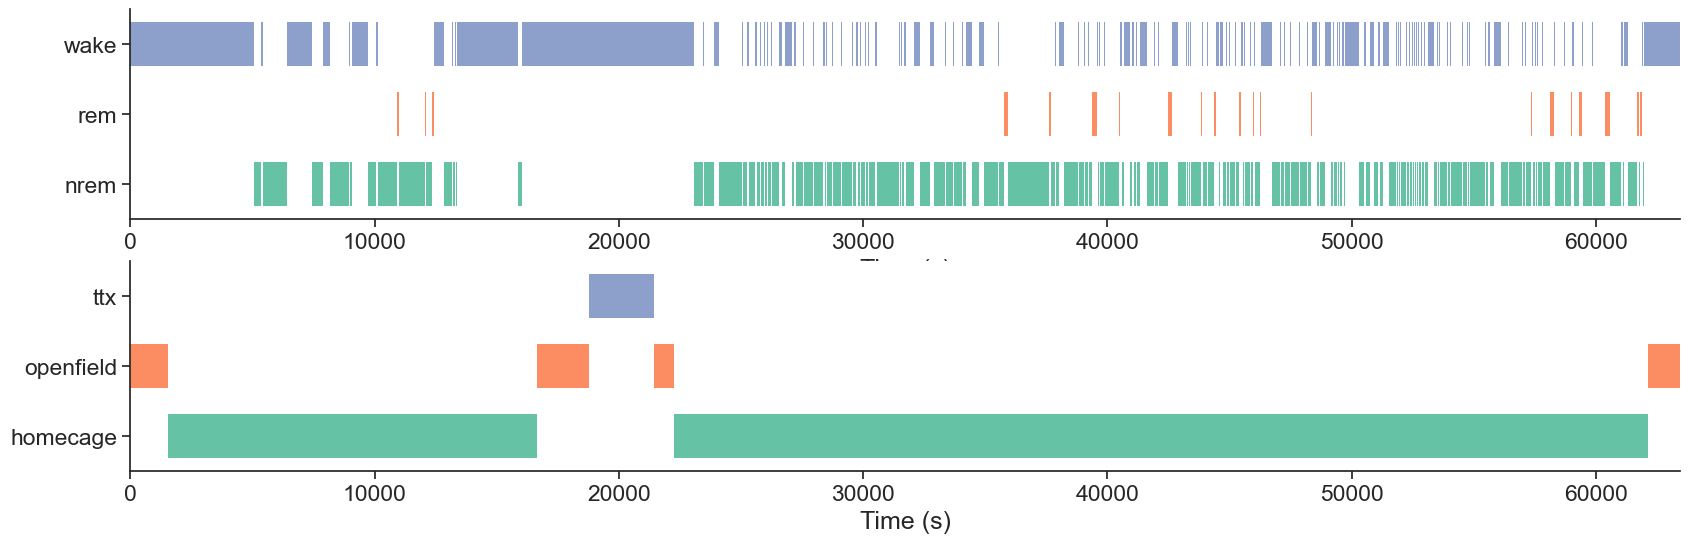

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 6))

plot_intervals(sleep_states, column='state', palette='Set2', ax=ax1)
plot_intervals(sessions, column='label', palette='Set2', ax=ax2)

plt.show()

### Wake manifold

wake_rates shape: (10548, 81)


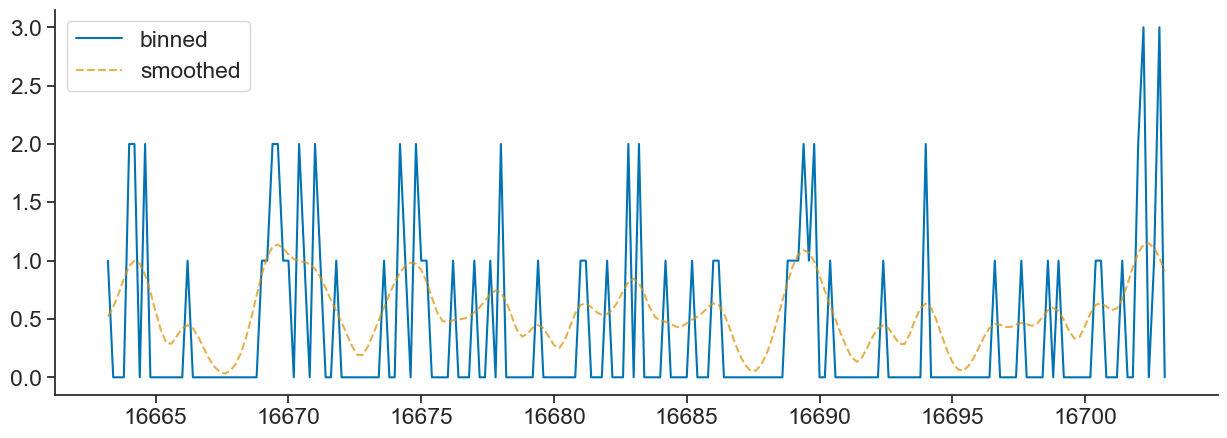

In [19]:
WAKE_BIN = 0.2
SMOOTH_STD = 0.4

angle = circ_bin_average(hd_angle, bin_size=WAKE_BIN)
binned = hd_spikes.count(bin_size=WAKE_BIN, ep=hd_angle.time_support)
wake_rates = np.sqrt(binned.smooth(std=SMOOTH_STD))
print(f"wake_rates shape: {wake_rates.shape}")

# Visualize Smoothing effect
t_a, t_b = 0, 200
channel = 7

plt.figure(figsize=(15, 5))
plt.plot(binned[t_a:t_b, channel])
plt.plot(wake_rates[t_a:t_b, channel], '--', alpha=0.7)
plt.legend(['binned', 'smoothed'])
plt.show()

<Axes: >

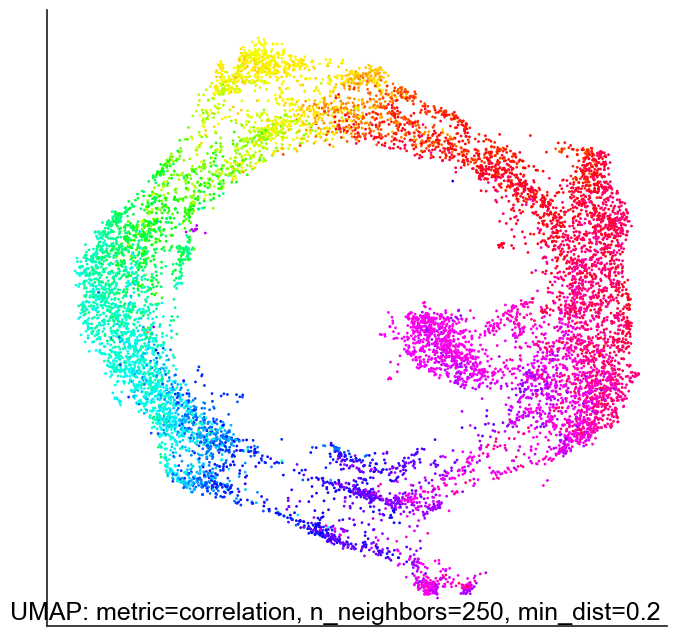

In [20]:
UMAP_NEIGHBORS = 250
UMAP_MIN_DIST = 0.2

reducer = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=2, metric='correlation')
reducer.fit(wake_rates)
uplot.points(reducer, values=angle.values, cmap='hsv')

In [18]:
manifold_openfield = nap.TsdFrame(t=wake_rates.times(), d=np.concatenate([reducer.embedding_, angle.values[:, None]], axis=1), columns=['x', 'y', 'angle'])
manifold_openfield.save(PROCESSED_DATA_PATH / unit_id / "manifold_openfield.npz")

### Post-TTX Manifold

wake_rates shape: (10624, 81)


<Axes: >

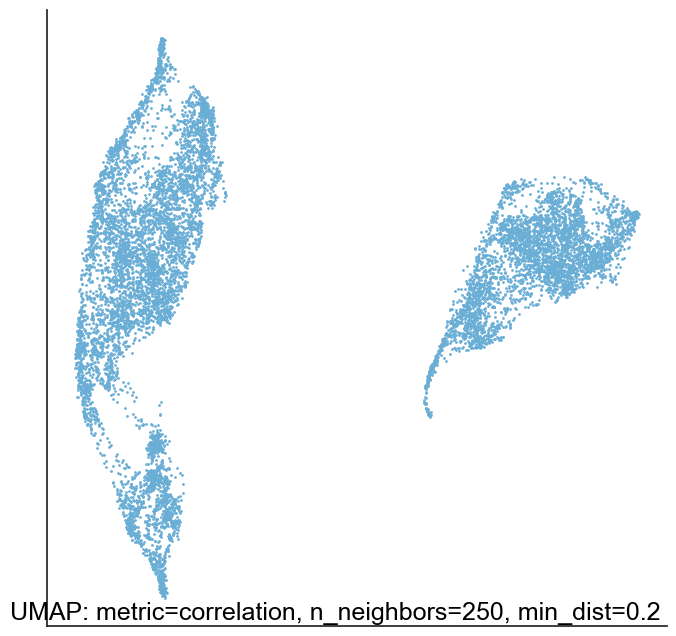

In [31]:
ep = sessions[sessions['label'] == 'openfield'][2:]

angle = circ_bin_average(hd_angle, bin_size=WAKE_BIN)
binned = hd_spikes.count(bin_size=WAKE_BIN, ep=ep)
wake_rates = np.sqrt(binned.smooth(std=SMOOTH_STD))
print(f"wake_rates shape: {wake_rates.shape}")

r = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=2, metric='correlation')
r.fit(wake_rates)
uplot.points(r)

In [32]:
embds = reducer.transform(wake_rates)

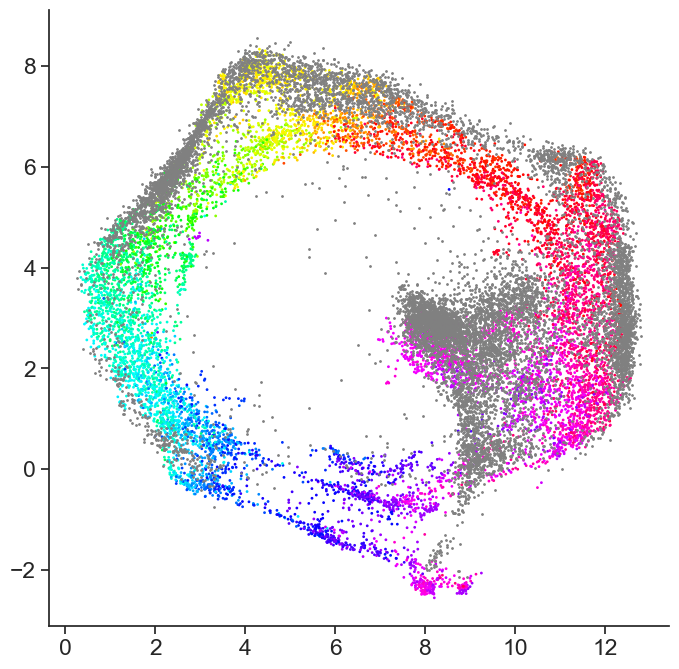

In [33]:
plt.figure(figsize=(8, 8))
plt.scatter(reducer.embedding_[:, 0], reducer.embedding_[:, 1], c=angle.values, cmap='hsv', s=1)
plt.scatter(embds[:, 0], embds[:, 1], c='gray', s=1) 

### NREM projection

In [13]:
epochs = sessions[sessions['label'] == 'homecage'][1]

NREM_BIN = 0.05
SMOOTH_STD = 0.1

binned = hd_spikes.count(bin_size=NREM_BIN, ep=epochs)
smooth_rate = np.sqrt(binned.smooth(std=SMOOTH_STD))
print(f"smooth_rate shape: {smooth_rate.shape}")

smooth_rate shape: (797302, 81)


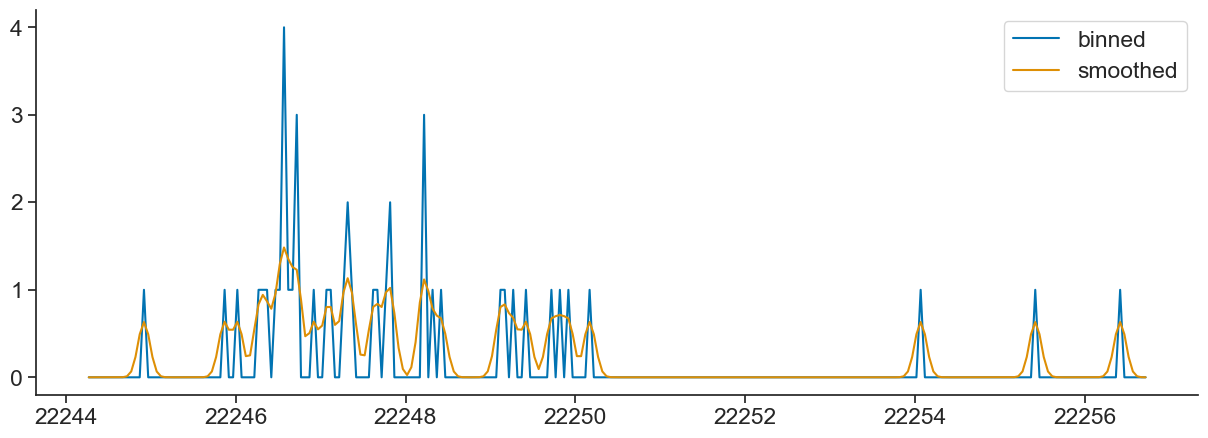

In [16]:
# Visualize smoothing effect
t_a, t_b = 0, 250
channel = 8

plt.figure(figsize=(15, 5))
plt.plot(binned[t_a:t_b, channel])
plt.plot(smooth_rate[t_a:t_b, channel])
plt.legend(['binned', 'smoothed'])
plt.show()

In [18]:
wake_rates, w_t = wake_rates.to_numpy(), wake_rates.times()
smooth_rate, s_t = smooth_rate.to_numpy(), smooth_rate.times()

print(f"wake_rates shape: {wake_rates.shape}")
print(f"smooth_rate shape: {smooth_rate.shape}")
print(f"wake_rates time range: {w_t[0]} to {w_t[-1]}")
print(f"smooth_rate time range: {s_t[0]} to {s_t[-1]}")

wake_rates shape: (10548, 81)
smooth_rate shape: (797302, 81)
wake_rates time range: 16663.2 to 18772.6
smooth_rate time range: 22244.26845 to 62109.31845


In [ ]:
sleep_embds = reducer.transform(smooth_rate)
manifold = nap.TsdFrame(t=s_t, d=sleep_embds, columns=['x', 'y'])

In [25]:
manifold.save(PROCESSED_DATA_PATH / unit_id / "manifold_post.npz")